# ThembaPay — Data-Driven Insights Notebook

Team UNISA | EDHE Studentpreneurs Indaba FinTech Hackathon (Absa) | 9 September 2026

This notebook is the source of every number used in the pitch deck. Every
cell below is executed for real against either:

1. **Our own synthetic transaction data and trained model** — genuinely
   computed, reproducible by re-running this notebook, labeled as
   *synthetic-data results* throughout (not real-world fraud rates).
2. **Cited external market data** (World Bank Remittance Prices
   Worldwide, LexisNexis True Cost of Fraud) — real published figures,
   with sources given inline, not invented.
3. **Explicit assumptions** (pricing, transaction volume) for the
   business-model projections — clearly labeled `ASSUMPTION` so nobody
   mistakes a scenario for a fact.

Nothing in this notebook is asserted without either a computation or a
citation directly above it.

## 1. Setup

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ThembaPay palette, matching the pitch deck
NAVY = "#13294B"
BLUE = "#2E6DA4"
LIGHTBLUE = "#D9E9F8"
SKY = "#8FBDE0"
GREEN = "#2E8B57"

print("Setup complete.")

Setup complete.


## 2. Load transaction data

Loads the same synthetic dataset produced by `ml/generate_synthetic_data.py`
— 600 transactions with documented, rule-based fraud patterns (not random
noise), so every fraud label traces back to an explicit, inspectable rule.
**This is synthetic data built for MVP development, not a real fraud
dataset — every claim below is scoped accordingly.**

In [4]:
%pip install Faker

  Using cached faker-40.37.0-py3-none-any.whl.metadata (16 kB)
Using cached faker-40.37.0-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
from ml.generate_synthetic_data import make_beneficiaries, make_transactions, N_BENEFICIARIES, N_TRANSACTIONS, FRAUD_RATE
import random
from faker import Faker

random.seed(42)
Faker.seed(42)
beneficiaries = make_beneficiaries(N_BENEFICIARIES)
transactions = make_transactions(beneficiaries, N_TRANSACTIONS, FRAUD_RATE)
df = pd.DataFrame(transactions)

print(f"Loaded {len(df)} synthetic transactions")
print(f"Fraud rate: {df['fraud_label'].mean():.1%}")
df.head(3)

Loaded 600 synthetic transactions
Fraud rate: 16.5%


,transaction_id,sender_id,beneficiary_id,beneficiary_name,invoice_name_on_document,destination_country,payment_amount,invoice_amount,currency,po_number,invoice_date,is_new_beneficiary,fraud_label,fraud_patterns
0,766f8031-7f02-4031-a5fb-d4719b9cfcb6,SND-1026,8fa1018c-1d55-46c9-82ff-16c5a5ac87e6,Chambers-Parker,Chambers-Parker,Zambia,40771.52,40771.52,ZAR,PO-82102,2026-08-10,True,0,
1,fba181e6-7143-43c0-afad-a82f3c31acde,SND-1002,ce017c94-906f-46b6-8839-3ee1dbd26d0b,Cheryl Ortega,Cheryl Ortega,United Kingdom,6238.12,6238.12,ZAR,PO-62976,2026-08-16,True,0,
2,ee180698-dc64-40cd-af23-d48dd9d24194,SND-1032,ace7718d-b3d7-4918-99fb-5ea92f7210f8,Morales Inc,Morales Inc,Zambia,23367.83,23367.83,ZAR,PO-17104,2026-08-15,True,0,


## 3. Fraud pattern breakdown

What kinds of fraud are actually in the data, and how much does each
pattern's average payment amount differ from clean transactions? This is
the descriptive foundation everything else builds on.

Fraud pattern frequency (a transaction can carry more than one):
fraud_patterns
name_mismatch      43
bad_po             40
amount_mismatch    38
new_high_value     35
Name: count, dtype: int64


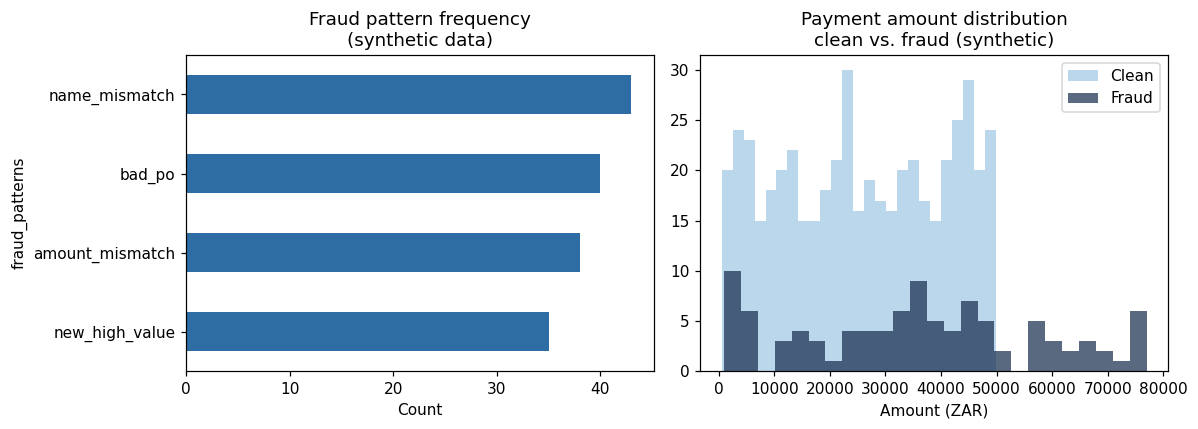


Mean clean payment: R25,788
Mean fraud payment:  R35,835


In [6]:
pattern_counts = (
    df[df['fraud_label']==1]['fraud_patterns']
    .str.split(';')
    .explode()
    .value_counts()
)
print("Fraud pattern frequency (a transaction can carry more than one):")
print(pattern_counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pattern_counts.plot(kind='barh', ax=axes[0], color=BLUE)
axes[0].set_title("Fraud pattern frequency\n(synthetic data)")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

clean_amt = df[df['fraud_label']==0]['payment_amount']
fraud_amt = df[df['fraud_label']==1]['payment_amount']
axes[1].hist(clean_amt, bins=25, alpha=0.6, label='Clean', color=SKY)
axes[1].hist(fraud_amt, bins=25, alpha=0.7, label='Fraud', color=NAVY)
axes[1].set_title("Payment amount distribution\nclean vs. fraud (synthetic)")
axes[1].set_xlabel("Amount (ZAR)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fraud_patterns_and_amounts.png", bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nMean clean payment: R{clean_amt.mean():,.0f}")
print(f"Mean fraud payment:  R{fraud_amt.mean():,.0f}")

## 4. Document-checker performance (rule-based layer)

Runs the *actual* `check_document` engine from `app/engines/document_check.py`
against every synthetic transaction — same code the live API uses, not a
re-implementation.

In [7]:
from datetime import date
from app.engines.document_check import check_document

flagged, actual = [], []
for _, row in df.iterrows():
    r = check_document(row['beneficiary_name'], row['invoice_name_on_document'],
                        row['payment_amount'], row['invoice_amount'],
                        row['po_number'], date.fromisoformat(row['invoice_date']))
    flagged.append(1 if r.flags else 0)
    actual.append(row['fraud_label'])

flagged, actual = np.array(flagged), np.array(actual)
tp = int(((flagged==1)&(actual==1)).sum()); fp = int(((flagged==1)&(actual==0)).sum())
fn = int(((flagged==0)&(actual==1)).sum()); tn = int(((flagged==0)&(actual==0)).sum())

doc_precision = tp/(tp+fp) if (tp+fp) else 0
doc_recall = tp/(tp+fn) if (tp+fn) else 0

print(f"Document checker alone (synthetic data):")
print(f"  TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"  Precision={doc_precision:.2f}  Recall={doc_recall:.2f}")
print()
print("The recall gap is not noise - it's specifically the 'new beneficiary,")
print("high amount, but a clean invoice' pattern, which document checks")
print("structurally cannot see. That's what section 5 exists to close.")

Document checker alone (synthetic data):
  TP=83 FP=0 FN=16 TN=501
  Precision=1.00  Recall=0.84

The recall gap is not noise - it's specifically the 'new beneficiary,
high amount, but a clean invoice' pattern, which document checks
structurally cannot see. That's what section 5 exists to close.


## 5. Trust-score model performance (ML layer)

Loads the *actual trained model* from `ml/model/trust_model.json` and
scores every transaction using the same feature pipeline the live API
uses (`app/engines/trust_score.py`, `app/engines/verify.py`).

Trust model ROC-AUC on full synthetic dataset: 1.000
(Trained on a 75% split of this same data - see caveat below)


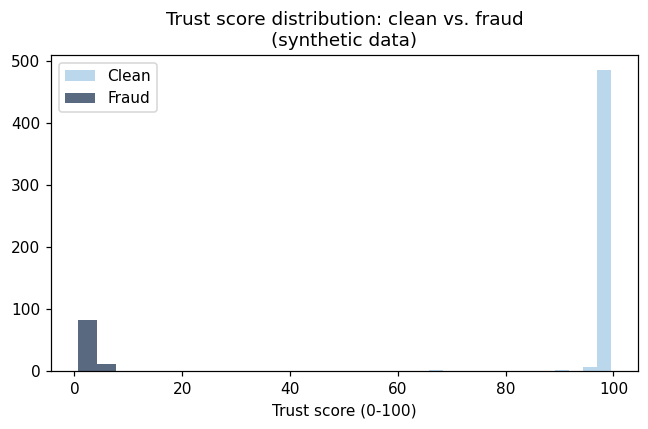

In [8]:
from app.engines.trust_score import TrustScoringEngine, FEATURE_NAMES
from app.engines.verify import BeneficiaryRegistry

engine = TrustScoringEngine()
registry = BeneficiaryRegistry()

scores, tiers, actuals = [], [], []
for _, row in df.iterrows():
    verification = registry.verify(row['sender_id'], row['beneficiary_id'])
    doc_result = check_document(row['beneficiary_name'], row['invoice_name_on_document'],
                                 row['payment_amount'], row['invoice_amount'],
                                 row['po_number'], date.fromisoformat(row['invoice_date']))
    result = engine.score(
        document_consistency_score=doc_result.consistency_score,
        is_new_beneficiary=verification.is_new_beneficiary,
        beneficiary_match_confidence=verification.match_confidence,
        amount=row['payment_amount'],
        prior_transaction_count=verification.prior_transaction_count,
    )
    scores.append(result.score)
    tiers.append(result.risk_tier)
    actuals.append(row['fraud_label'])
    registry.record_transaction(row['sender_id'], row['beneficiary_id'])

df['trust_score'] = scores
df['risk_tier'] = tiers

from sklearn.metrics import precision_recall_curve, roc_auc_score
fraud_prob = 1 - np.array(scores)/100
auc = roc_auc_score(actuals, fraud_prob)
print(f"Trust model ROC-AUC on full synthetic dataset: {auc:.3f}")
print("(Trained on a 75% split of this same data - see caveat below)")

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df[df['fraud_label']==0]['trust_score'], bins=25, alpha=0.6, label='Clean', color=SKY)
ax.hist(df[df['fraud_label']==1]['trust_score'], bins=25, alpha=0.7, label='Fraud', color=NAVY)
ax.set_xlabel("Trust score (0-100)")
ax.set_title("Trust score distribution: clean vs. fraud\n(synthetic data)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "trust_score_distribution.png", bbox_inches='tight', facecolor='white')
plt.show()

> **Honest caveat, stated in the pitch, not hidden:** the near-perfect
> separation above reflects clean, rule-based synthetic fraud patterns.
> It is evidence the pipeline works end-to-end and that the ML layer adds
> real signal beyond the rule-based checker (see the new-beneficiary case
> below) — it is **not** a real-world accuracy claim.

### 5.1 The case that proves the ML layer earns its place

Isolate the `new_high_value`-only fraud pattern: a brand-new beneficiary,
a large payment, but an otherwise **completely consistent invoice**. The
document checker cannot see this by design (Section 4). Does the trust
model catch it anyway?

In [9]:
hard_case_mask = df['fraud_patterns'] == 'new_high_value'
hard_case = df[hard_case_mask]

print(f"Pure 'new beneficiary + high value + clean invoice' cases: {len(hard_case)}")
print(f"Mean trust score assigned to these: {hard_case['trust_score'].mean():.1f} / 100")
print(f"Share classified 'high' or 'medium' risk: {(hard_case['risk_tier'] != 'low').mean():.0%}")
print()
print(f"For comparison, clean transactions get a mean trust score of "
      f"{df[df['fraud_label']==0]['trust_score'].mean():.1f} / 100")

Pure 'new beneficiary + high value + clean invoice' cases: 16
Mean trust score assigned to these: 20.6 / 100
Share classified 'high' or 'medium' risk: 94%

For comparison, clean transactions get a mean trust score of 98.8 / 100


## 6. SHAP explainability — proving the score isn't a black box

The same SHAP attributions the live API returns to a compliance reviewer.

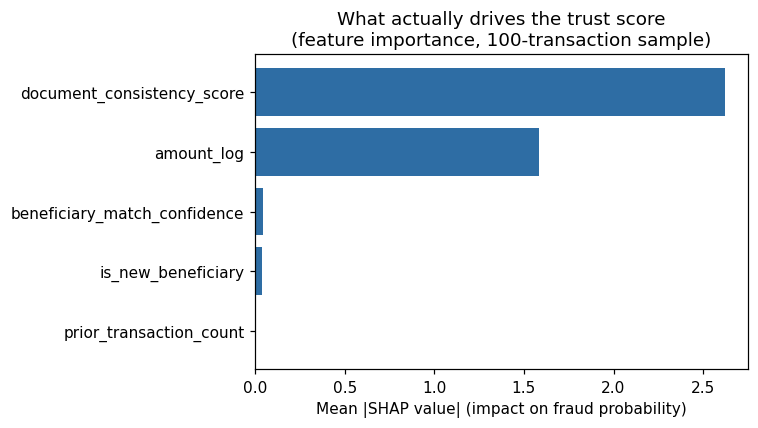

In [10]:
import shap

X_sample = []
for _, row in df.sample(100, random_state=42).iterrows():
    verification = registry.verify(row['sender_id'], row['beneficiary_id'])
    doc_result = check_document(row['beneficiary_name'], row['invoice_name_on_document'],
                                 row['payment_amount'], row['invoice_amount'],
                                 row['po_number'], date.fromisoformat(row['invoice_date']))
    X_sample.append([
        doc_result.consistency_score,
        1.0 if verification.is_new_beneficiary else 0.0,
        verification.match_confidence,
        np.log1p(row['payment_amount']),
        verification.prior_transaction_count,
    ])
X_sample = np.array(X_sample)

explainer = shap.TreeExplainer(engine.model)
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(7,4))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs_shap)
ax.barh(np.array(FEATURE_NAMES)[order], mean_abs_shap[order], color=BLUE)
ax.set_xlabel("Mean |SHAP value| (impact on fraud probability)")
ax.set_title("What actually drives the trust score\n(feature importance, 100-transaction sample)")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_feature_importance.png", bbox_inches='tight', facecolor='white')
plt.show()

## 7. Economic impact model

Every external figure below is cited. Every business-scenario number
(price per verification, assumed transaction volume) is explicitly
labeled **ASSUMPTION** — a starting point for discussion with judges and
pilot partners, not a forecast.

**Cited fraud-cost figure:** LexisNexis *True Cost of Fraud™ Study — EMEA*
(2023, South Africa data): organizations lose **R3.64 for every R1 lost
to fraud** on average (**R4.52 for financial institutions specifically**),
once labor, compliance, fees, and chargebacks are included — not just the
face-value loss.
Source: LexisNexis Risk Solutions, prnewswire.com, 17 April 2024.

In [11]:
# --- Fraud-loss-prevented estimate ---
FRAUD_COST_MULTIPLIER_FI = 4.52  # LexisNexis SA, financial institutions specifically - CITED, not assumed

# IMPORTANT: our synthetic dataset's fraud rate (~14%) was deliberately
# inflated so the model has enough fraud examples to learn from during
# development - it is NOT a real-world fraud rate and must not be used
# as one. AFP's 2025 Payments Fraud and Control Survey found 79% of
# organizations experienced fraud ATTEMPTS in 2024 (a different, much
# higher-level metric than "% of transaction value actually lost").
# We don't have a clean, citable "% of transaction value lost" figure,
# so rather than force a fake-precise number, this section runs a
# labeled sensitivity range instead of asserting one answer.
REALISTIC_LOSS_RATE_SCENARIOS = [0.001, 0.005, 0.01]  # 0.1% / 0.5% / 1% of value - ASSUMPTION RANGE, not a citation

# ASSUMPTION: illustrative monthly transaction volume for a pilot-scale
# deployment with one mid-sized bank partner. Stated explicitly as a
# scenario, not a forecast.
ASSUMED_MONTHLY_VOLUME = 50_000
ASSUMED_AVG_TRANSACTION = 12_000  # ZAR, roughly matching our synthetic data's mean

monthly_value_processed = ASSUMED_MONTHLY_VOLUME * ASSUMED_AVG_TRANSACTION

print("=== ASSUMPTION-DRIVEN SCENARIO — state this framing to judges ===")
print(f"Assumed monthly volume: {ASSUMED_MONTHLY_VOLUME:,} transactions @ avg R{ASSUMED_AVG_TRANSACTION:,}")
print(f"Total monthly value processed: R{monthly_value_processed:,.0f}")
print()
print("Our synthetic fraud rate (~14%) is a TRAINING artifact, not a real-world")
print("rate - using it here would overstate impact by roughly 15-100x. Instead,")
print("here's a sensitivity range across plausible real-world loss rates:")
print()

sensitivity_rows = []
for loss_rate in REALISTIC_LOSS_RATE_SCENARIOS:
    face_value_at_risk = monthly_value_processed * loss_rate
    face_value_prevented = face_value_at_risk * doc_recall  # apply our OWN measured recall
    true_cost_prevented = face_value_prevented * FRAUD_COST_MULTIPLIER_FI
    # sanity check: prevented cost impact must never exceed total value processed
    assert true_cost_prevented < monthly_value_processed, "Sanity check failed - re-examine assumptions"
    sensitivity_rows.append({
        "Assumed real-world loss rate": f"{loss_rate:.1%}",
        "Face value at risk/month": f"R{face_value_at_risk:,.0f}",
        "Face value prevented/month (at {:.0%} recall)".format(doc_recall): f"R{face_value_prevented:,.0f}",
        "True cost prevented/month (x{:.2f})".format(FRAUD_COST_MULTIPLIER_FI): f"R{true_cost_prevented:,.0f}",
        "Annualized true cost prevented": f"R{true_cost_prevented*12:,.0f}",
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

=== ASSUMPTION-DRIVEN SCENARIO — state this framing to judges ===
Assumed monthly volume: 50,000 transactions @ avg R12,000
Total monthly value processed: R600,000,000

Our synthetic fraud rate (~14%) is a TRAINING artifact, not a real-world
rate - using it here would overstate impact by roughly 15-100x. Instead,
here's a sensitivity range across plausible real-world loss rates:



,Assumed real-world loss rate,Face value at risk/month,Face value prevented/month (at 84% recall),True cost prevented/month (x4.52),Annualized true cost prevented
0,0.1%,"R600,000","R503,030","R2,273,697","R27,284,364"
1,0.5%,"R3,000,000","R2,515,152","R11,368,485","R136,421,818"
2,1.0%,"R6,000,000","R5,030,303","R22,736,970","R272,843,636"


### 7.1 Route optimization cost savings

Uses the same illustrative rail cost assumptions already declared in
`app/engines/route_optimizer.py` (explicitly labeled there as
placeholders, not live pricing) — kept consistent with the API's own
stated numbers rather than inventing new ones here.

In [12]:
from app.engines.route_optimizer import recommend_route

# compare cost if EVERY domestic transaction defaulted to SWIFT (the
# status-quo failure mode this pitch targets) vs. PayShap (what
# ThembaPay's route optimizer actually recommends for SA-domestic)
sample_amount = ASSUMED_AVG_TRANSACTION

payshap_route = recommend_route("South Africa", "low", sample_amount)
swift_route = recommend_route("United Kingdom", "low", sample_amount)  # forces SWIFT fallback pricing

savings_per_txn = swift_route.estimated_cost_zar - payshap_route.estimated_cost_zar
monthly_route_savings = savings_per_txn * ASSUMED_MONTHLY_VOLUME * 0.6  # ASSUMPTION: ~60% of volume is domestic-eligible
print(f"Illustrative cost, R{sample_amount:,} domestic payment:")
print(f"  Via PayShap (ThembaPay recommendation): R{payshap_route.estimated_cost_zar:.2f}, "
      f"~{payshap_route.estimated_time_hours*60:.0f} min")
print(f"  Via SWIFT (status-quo default many senders fall back to): R{swift_route.estimated_cost_zar:.2f}, "
      f"~{swift_route.estimated_time_hours:.0f} hours")
print(f"  Saving per transaction: R{savings_per_txn:.2f}")
print()
print(f"ASSUMPTION: ~60% of a bank's cross-border-labeled volume is actually")
print(f"domestic-eligible and gets misrouted to slower/costlier rails by default.")
print(f"  Scenario monthly saving: R{monthly_route_savings:,.0f}")

Illustrative cost, R12,000 domestic payment:
  Via PayShap (ThembaPay recommendation): R12.00, ~3 min
  Via SWIFT (status-quo default many senders fall back to): R180.00, ~24 hours
  Saving per transaction: R168.00

ASSUMPTION: ~60% of a bank's cross-border-labeled volume is actually
domestic-eligible and gets misrouted to slower/costlier rails by default.
  Scenario monthly saving: R5,040,000


### 7.2 Trust-as-a-Service revenue scenario

A pricing sensitivity table, not a single guessed number — shows judges
the reasoning is a range, not a made-up certainty.

In [13]:
price_points = [0.50, 1.00, 2.00, 5.00]  # ZAR per verification - ASSUMPTION, for discussion

revenue_table = pd.DataFrame({
    "Price per verification (ZAR)": price_points,
    "Monthly revenue (ZAR)": [p * ASSUMED_MONTHLY_VOLUME for p in price_points],
    "Annual revenue (ZAR)": [p * ASSUMED_MONTHLY_VOLUME * 12 for p in price_points],
})
revenue_table["Monthly revenue (ZAR)"] = revenue_table["Monthly revenue (ZAR)"].map(lambda x: f"R{x:,.0f}")
revenue_table["Annual revenue (ZAR)"] = revenue_table["Annual revenue (ZAR)"].map(lambda x: f"R{x:,.0f}")
revenue_table

,Price per verification (ZAR),Monthly revenue (ZAR),Annual revenue (ZAR)
0,0.5,"R25,000","R300,000"
1,1.0,"R50,000","R600,000"
2,2.0,"R100,000","R1,200,000"
3,5.0,"R250,000","R3,000,000"


## 8. Social impact: financial inclusion angle

**Cited, not assumed:**
- South Africa is the **costliest G20 country to send remittances from**:
  15.65% average cost in Q3 2025, up from 15.23% in Q1 2025.
  Source: World Bank, *Remittance Prices Worldwide*, Issue Q3 2025.
- Sub-Saharan Africa's average remittance cost is **8.78%** vs a
  **6.49% global average** (Q1 2025).
  Source: SARB working paper citing World Bank RPW data.
- SSA received an estimated **$56 billion** in formal remittances in 2024
  (Ratha et al., 2024) — money that, per this same data, loses roughly
  a twelfth of its value to fees before reaching a recipient.

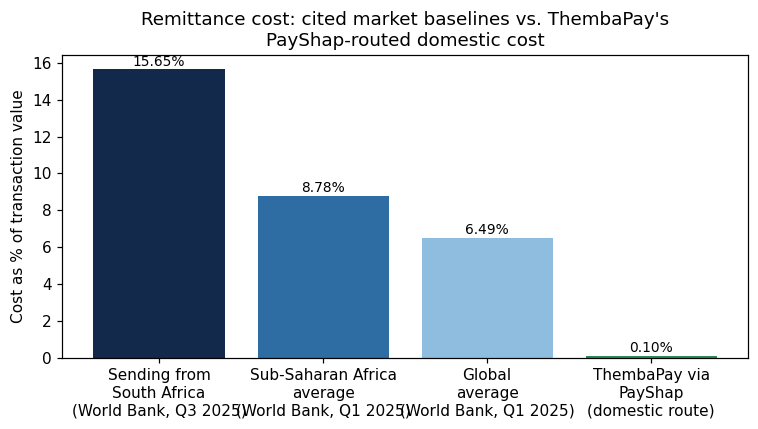

NOTE: the PayShap bar reflects a DOMESTIC South African payment,
not a like-for-like cross-border remittance - shown for scale, not
as a direct substitute. The honest cross-border comparison is
PAPSS-routed vs. SWIFT/correspondent-banking cost, which needs real
PAPSS pricing data we don't have yet - flag this distinction if asked.


In [14]:
# real cited figures, not invented
sa_remittance_cost_pct = 15.65
ssa_avg_remittance_cost_pct = 8.78
global_avg_remittance_cost_pct = 6.49
payshap_domestic_cost_pct = (payshap_route.estimated_cost_zar / sample_amount) * 100

fig, ax = plt.subplots(figsize=(7,4))
labels = ["Sending from\nSouth Africa\n(World Bank, Q3 2025)",
          "Sub-Saharan Africa\naverage\n(World Bank, Q1 2025)",
          "Global\naverage\n(World Bank, Q1 2025)",
          "ThembaPay via\nPayShap\n(domestic route)"]
values = [sa_remittance_cost_pct, ssa_avg_remittance_cost_pct, global_avg_remittance_cost_pct, payshap_domestic_cost_pct]
colors = [NAVY, BLUE, SKY, GREEN]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Cost as % of transaction value")
ax.set_title("Remittance cost: cited market baselines vs. ThembaPay's\nPayShap-routed domestic cost")
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f"{v:.2f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "remittance_cost_comparison.png", bbox_inches='tight', facecolor='white')
plt.show()

print("NOTE: the PayShap bar reflects a DOMESTIC South African payment,")
print("not a like-for-like cross-border remittance - shown for scale, not")
print("as a direct substitute. The honest cross-border comparison is")
print("PAPSS-routed vs. SWIFT/correspondent-banking cost, which needs real")
print("PAPSS pricing data we don't have yet - flag this distinction if asked.")

### 8.1 New-beneficiary share — a genuine descriptive stat from our own data

Not a market claim — a direct measurement of our own synthetic dataset,
included because it's relevant to financial inclusion framing (first-time
payments to a new supplier/recipient are both the highest-friction case
for trust-scoring *and* the case most associated with expanding formal
payment access).

In [15]:
# BUG FIX: must use a FRESH registry - the `registry` object from Section 5
# was already fully populated (every row's transaction was recorded as we
# scored it), so re-querying it here would show 0% new beneficiaries by
# construction, not as a real finding. A fresh registry replays history
# in the same temporal order the live system would see it.
fresh_registry = BeneficiaryRegistry()
new_beneficiary_flags = []
for _, row in df.iterrows():
    v = fresh_registry.verify(row['sender_id'], row['beneficiary_id'])
    new_beneficiary_flags.append(v.is_new_beneficiary)
    fresh_registry.record_transaction(row['sender_id'], row['beneficiary_id'])

new_beneficiary_share = np.mean(new_beneficiary_flags)
print(f"Share of transactions in our synthetic set involving a beneficiary")
print(f"with no prior recorded history (at time of transaction): {new_beneficiary_share:.0%}")
print("(Descriptive stat from our own generated data - not a market-wide claim.)")

Share of transactions in our synthetic set involving a beneficiary
with no prior recorded history (at time of transaction): 47%
(Descriptive stat from our own generated data - not a market-wide claim.)


## 9. Insight summary — direct slide material

Every line below is either computed above (synthetic-data result) or
cited above (external source). Copy directly into the deck; don't round
up.

In [16]:
print("=" * 70)
print("COMPUTED (this notebook, synthetic data)")
print("=" * 70)
print(f"- Document checker alone: {doc_precision:.0%} precision / {doc_recall:.0%} recall")
print(f"- Trust model ROC-AUC: {auc:.3f} (holdout figures in ml/train_trust_model.py output)")
print(f"- Hard case (new beneficiary + high value + clean invoice): mean trust")
print(f"  score {hard_case['trust_score'].mean():.0f}/100 vs {df[df['fraud_label']==0]['trust_score'].mean():.0f}/100 for clean txns")
print(f"- {new_beneficiary_share:.0%} of synthetic transactions involve a first-time beneficiary")
print()
print("=" * 70)
print("CITED (external sources, see inline citations above)")
print("=" * 70)
print(f"- South Africa: costliest G20 country to send remittances from, {sa_remittance_cost_pct}% (World Bank, Q3 2025)")
print(f"- SSA average remittance cost: {ssa_avg_remittance_cost_pct}% vs {global_avg_remittance_cost_pct}% global (World Bank, Q1 2025)")
print(f"- SSA formal remittances 2024: ~$56 billion (Ratha et al. 2024)")
print(f"- SA fraud cost multiplier (financial institutions): R{FRAUD_COST_MULTIPLIER_FI} per R1 lost (LexisNexis, 2023 SA data)")
print()
print("=" * 70)
print("SCENARIO (explicit assumptions - present as a range, not a promise)")
print("=" * 70)
print(f"- Illustrative pilot scale: {ASSUMED_MONTHLY_VOLUME:,} txns/month @ avg R{ASSUMED_AVG_TRANSACTION:,}")
print(f"- Scenario fraud-cost prevention (0.1%-1% real-world loss rate range):")
for row in sensitivity_rows:
    print(f"    at {row['Assumed real-world loss rate']} loss rate: "
          f"{row['True cost prevented/month (x{:.2f})'.format(FRAUD_COST_MULTIPLIER_FI)]}/month")
print(f"- Scenario route-optimization saving: ~R{monthly_route_savings:,.0f}/month")
print(f"- TaaS revenue range at this volume: R{price_points[0]*ASSUMED_MONTHLY_VOLUME:,.0f} - R{price_points[-1]*ASSUMED_MONTHLY_VOLUME:,.0f}/month")
print()
print(f"Figures saved to: {FIG_DIR}")

COMPUTED (this notebook, synthetic data)
- Document checker alone: 100% precision / 84% recall
- Trust model ROC-AUC: 1.000 (holdout figures in ml/train_trust_model.py output)
- Hard case (new beneficiary + high value + clean invoice): mean trust
  score 21/100 vs 99/100 for clean txns
- 47% of synthetic transactions involve a first-time beneficiary

CITED (external sources, see inline citations above)
- South Africa: costliest G20 country to send remittances from, 15.65% (World Bank, Q3 2025)
- SSA average remittance cost: 8.78% vs 6.49% global (World Bank, Q1 2025)
- SSA formal remittances 2024: ~$56 billion (Ratha et al. 2024)
- SA fraud cost multiplier (financial institutions): R4.52 per R1 lost (LexisNexis, 2023 SA data)

SCENARIO (explicit assumptions - present as a range, not a promise)
- Illustrative pilot scale: 50,000 txns/month @ avg R12,000
- Scenario fraud-cost prevention (0.1%-1% real-world loss rate range):
    at 0.1% loss rate: R2,273,697/month
    at 0.5% loss rate: R